<a href="https://colab.research.google.com/github/mikakia/AdvanceML_Final_Project/blob/main/blasto_ss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from PIL import Image

## Before running:
Change shortcut to data.

For Ieva: 'content/drive/MyDrive/Data'

For Mika:


In [12]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Change before running
ROOT_DIR = '/content/drive/MyDrive/Data'

blast_dir = os.path.join(ROOT_DIR, 'Blastocyst')
icm_dir = os.path.join(ROOT_DIR, 'GT_ICM')
te_dir = os.path.join(ROOT_DIR, 'GT_TE')
zp_dir = os.path.join(ROOT_DIR, 'GT_ZP')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# Creating Dataset class for our data

class BlastDataset(Dataset):
  MASK_NAMES = [' ICM', ' ZP', ' TE']

  def __init__(self, blast_dir, mask_dirs, transform=None):
    self.blast_dir = blast_dir
    self.mask_dirs = mask_dirs
    self.transform = transform
    # Create masterlist of Blastocyst names
    self.filenames = sorted([
        f for f in os.listdir(blast_dir) if f.endswith('.BMP')
    ])

  # Returns number of images
  def __len__(self):
    return len(self.filenames)

  # Takes a blastocyst name and returns corresponding mask filename
  def _get_mask_name(self, blast_filename, mask_name):
    stem = os.path.splitext(blast_filename)[0] # Retrieves only image name
    return f"{stem}{mask_name}_Mask.bmp"

  # Fetch one sample
  def __getitem__(self, index):
    fname = self.filenames[index]
    image = Image.open(os.path.join(self.blast_dir, fname)).convert('RGB')

    masks = []
    for mask_name, mask_dir in zip(self.MASK_NAMES, self.mask_dirs):
      mask_fname = self._get_mask_name(fname, mask_name)
      mask = Image.open(os.path.join(mask_dir,mask_fname)).convert('L') # Convert mask to grayscale
      masks.append(mask)

    if self.transform:
      image = self.transform(image)
      masks = [self.transform(m) for m in masks]

    return image, masks


dataset = BlastDataset(
    blast_dir=blast_dir,
    mask_dirs=[icm_dir, zp_dir, te_dir],
)

In [25]:
# Checking if any masks are missing
missing = []
for fname in dataset.filenames:
  for mask_name, mask_dir in zip(dataset.MASK_NAMES, dataset.mask_dirs):
    mask_fname = dataset._get_mask_name(fname, mask_name)
    full_path = os.path.join(mask_dir, mask_fname)
    if not os.path.exists(full_path):
      missing.append(full_path)

print(missing)

[]


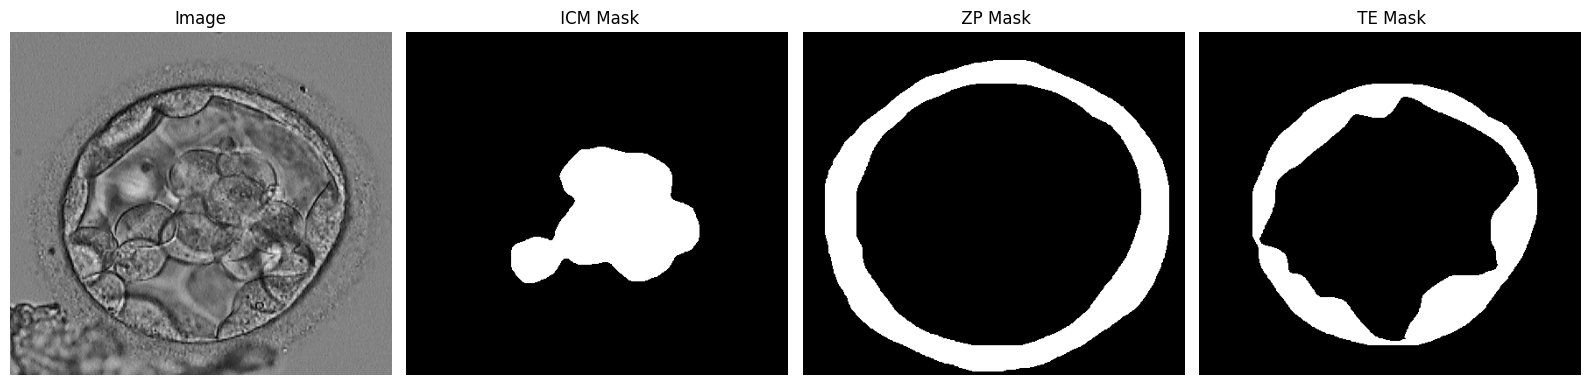

In [26]:
import matplotlib.pyplot as plt

dataset_viz = BlastDataset(
    blast_dir=blast_dir,
    mask_dirs=[icm_dir, zp_dir, te_dir]
)

image, masks = dataset_viz[0]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(image)
axes[0].set_title('Image')

for i, (mask, mask_name) in enumerate(zip(masks, [' ICM', ' ZP', ' TE'])):
  axes[i+1].imshow(mask, cmap='gray')
  axes[i+1].set_title(f'{mask_name} Mask')

for ax in axes:
  ax.axis('off')

plt.tight_layout()
plt.show()